# ML4ES — 2025/2026  
## Домашнее задание: классификация эпизодов загрязнения воздуха (Beijing AQ & Weather)  
### kNN, тривиальные модели, генеративные модели (Gaussian Naive Bayes)

**Контекст курса:** мы обсудили постановку задачи классификации, kNN и тривиальные модели; на следующей лекции переходим к вероятностной постановке и наивному Байесу.  
**Цель ДЗ:** на реальном датасете сравнить *тривиальные baselines*, *kNN* и *Gaussian Naive Bayes* и осознать, где и почему работают (или ломаются) предположения о распределениях.

> В блокноте есть места, где **код нужно написать самостоятельно**.  
> Они помечены `# TODO` и/или выбрасывают `NotImplementedError`.

---

## Описание датасета (ключевое)

Коллекция данных **Beijing Air Quality & Weather**: почасовые наблюдения (UTC+8) качества воздуха и метеопараметров в Пекине за 2010–2014 годы. Данные могут быть представлены отдельными CSV по станциям. Есть пропуски, сезонность, возможны экстремальные эпизоды смога. fileciteturn4file0

**Используемые колонки (как в раздаче):**

- `pm2.5` — концентрация PM2.5 (µg/m³) — из неё строим целевую переменную;
- `DEWP`, `TEMP`, `PRES` — метеопараметры (°C, °C, hPa);
- `Iws` — средняя скорость ветра (m/s);
- `Is`, `Ir` — накопленные часы снега/дождя (hr);
- `cbwd` — направление ветра (категориальная) — **опционально** (бонус).

---

## Что вы сдаёте

1. Заполненный блокнот `.ipynb`.
2. Короткие ответы на вопросы в конце.

**Оценивание:** корректность реализации, аккуратность эксперимента (split, стандартизация), интерпретация результатов.


## 0. Скачивание данных (обязательно сделать «ручками»)

Данные нужно скачать через браузер и положить в локальную папку проекта.

### Шаги

1. Откройте ссылку на архив с данными:  
   **https://ml4es.ru/links/uci-baq**

2. Скачайте архив (обычно это `.zip`).

3. Распакуйте архив так, чтобы в вашем проекте получилась структура (пример):

```
./
|-ML4ES2026-HW2.1-Classification_BeijingAQ.ipynb
|-data/
|------uci-baq/
|--------------(один или несколько .csv файлов)

```

- Папка `data/uci-baq/` должна содержать CSV-файлы с данными.
- Имена файлов могут отличаться — код ниже ищет CSV автоматически.

4. Запустите ячейку проверки: она покажет, что файлы на месте.

> Если у вас другая структура — **измените путь** `DATA_DIR` в разделе 2.


## 0.1. Метаданные датасета (из README)

Ниже — краткая выжимка (полное описание — в `README.md` в раздаче). fileciteturn4file0

- Формат: CSV, разделитель `,`, десятичный `.`  
- Дискретность: 1 час (каждая строка — одно часовое наблюдение)  
- Период: 2010–2014  
- Есть пропуски (`NA`), выраженная сезонность, возможны экстремальные пики `pm2.5`  
- Колонки времени: `year`, `month`, `day`, `hour` (UTC+8)  
- Основные признаки: `DEWP`, `TEMP`, `PRES`, `cbwd`, `Iws`, `Is`, `Ir`  
- Целевая переменная в этом ДЗ строится из `pm2.5`.


## 1. Импорт библиотек

In [1]:
import glob
import pathlib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier


/Users/mkrinitskiy/conda/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Воспроизводимость
SEED = 42
rng = np.random.default_rng(SEED)


## 2. Параметры запуска

In [3]:
# Папка с CSV-файлами датасета (см. инструкцию в разделе 0)
DATA_DIR = pathlib.Path("./data/uci-baq")

# Куда складывать результаты/картинки (если нужно)
OUT_DIR = pathlib.Path("./results_hw_beijing_aq")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR :", OUT_DIR.resolve())


DATA_DIR: /Volumes/MKSSD/Yandex.Disk.localized/_WORK/ML4ES/ML4ES-2025/Lect11/HW/data/uci-baq
OUT_DIR : /Volumes/MKSSD/Yandex.Disk.localized/_WORK/ML4ES/ML4ES-2025/Lect11/HW/results_hw_beijing_aq


In [4]:
# Проверка наличия данных
csv_files = sorted(glob.glob(str(DATA_DIR / "**" / "*.csv"), recursive=True))
print(f"Найдено CSV-файлов: {len(csv_files)}")
if len(csv_files) == 0:
    raise FileNotFoundError(
        "Не найдено ни одного CSV. Проверьте, что вы распаковали архив в ./data/uci-baq/ "
        "или поправьте переменную DATA_DIR."
    )
print("Примеры файлов:")
for f in csv_files[:10]:
    print(" -", f)


Найдено CSV-файлов: 1
Примеры файлов:
 - data/uci-baq/PRSA_data_2010.1.1-2014.12.31.csv


## 3. Чтение данных

In [5]:
# Чтение и объединение CSV (если их несколько)
dfs = []
for f in csv_files:
    df_part = pd.read_csv(f)
    dfs.append(df_part)

df = pd.concat(dfs, axis=0, ignore_index=True)
print("Shape:", df.shape)
df.head()


Shape: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [6]:
# Базовая проверка колонок (по README)
required_cols = ["year", "month", "day", "hour", "pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(
        "В данных отсутствуют обязательные колонки: "
        f"{missing}\n"
        "Проверьте, что вы скачали правильный архив (по ссылке из ДЗ) и что читаете правильные CSV."
    )

if "cbwd" not in df.columns:
    print("⚠️ Колонка 'cbwd' не найдена — это ок, бонус-часть про категориальный признак пропускайте.")

print("OK: обязательные колонки присутствуют.")


OK: обязательные колонки присутствуют.


In [7]:
# Соберём datetime (UTC+8, без преобразования TZ)
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")
df = df.sort_values("datetime").reset_index(drop=True)
df[["datetime", "pm2.5", "TEMP", "PRES"]].head()


,datetime,pm2.5,TEMP,PRES
0,2010-01-01 00:00:00,NaN,-11.0,1021.0
1,2010-01-01 01:00:00,NaN,-12.0,1020.0
2,2010-01-01 02:00:00,NaN,-11.0,1019.0
3,2010-01-01 03:00:00,NaN,-14.0,1019.0
4,2010-01-01 04:00:00,NaN,-12.0,1018.0


## 4. Разведочный анализ (EDA)

In [8]:
display(df.describe(include="all"))
print("\nNaN по колонкам (топ-15):")
display(df.isna().mean().sort_values(ascending=False).head(15))


/var/folders/zg/qw7fghs57x1bj90_km31rvpm0000gn/T/ipykernel_16769/2394172799.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  display(df.describe(include="all"))


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824,43824.000000,43824.000000,43824.000000,43824
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,43824
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SE,NaN,NaN,NaN,2010-01-01 00:00:00
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15290,NaN,NaN,NaN,1
first,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01 00:00:00
last,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-12-31 23:00:00
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,NaN,23.889140,0.052734,0.194916,NaN
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,NaN,50.010635,0.760375,1.415867,NaN
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,NaN,0.450000,0.000000,0.000000,NaN
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,NaN,1.790000,0.000000,0.000000,NaN



NaN по колонкам (топ-15):


pm2.5       0.047166
No          0.000000
year        0.000000
month       0.000000
day         0.000000
hour        0.000000
DEWP        0.000000
TEMP        0.000000
PRES        0.000000
cbwd        0.000000
Iws         0.000000
Is          0.000000
Ir          0.000000
datetime    0.000000
dtype: float64

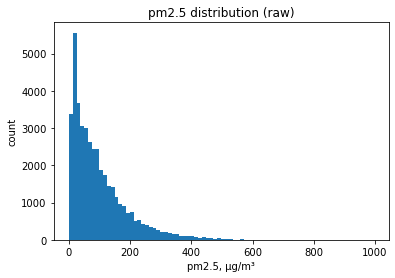

In [10]:
# Распределение pm2.5 (сырые данные)
pm = df["pm2.5"].dropna().values
plt.figure()
plt.hist(pm, bins=80)
plt.title("pm2.5 distribution (raw)")
plt.xlabel("pm2.5, µg/m³")
plt.ylabel("count")
plt.show()


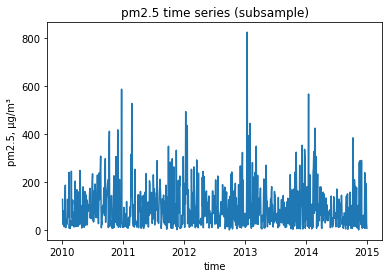

In [11]:
# (опционально) сезонность/динамика: pm2.5 vs время (подвыборка для скорости)
df_small = df.dropna(subset=["pm2.5", "datetime"]).iloc[::50].copy()
plt.figure()
plt.plot(df_small["datetime"].values, df_small["pm2.5"].values)
plt.title("pm2.5 time series (subsample)")
plt.xlabel("time")
plt.ylabel("pm2.5, µg/m³")
plt.show()


## 5. Постановка задачи классификации

### 5.1. Целевая переменная

Мы решаем бинарную задачу:

- `y = 1`, если **pm2.5 > 75** µg/m³  
- `y = 0`, если **pm2.5 ≤ 75** µg/m³

> Порог 75 выбран как «эпизод повышенного загрязнения» (условный операционный порог для учебной задачи).

**Важно:** в данных есть пропуски. Строки с пропуском в `pm2.5` или в выбранных признаках использовать нельзя.


In [12]:
FEATURES_NUM = ["DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]
THRESHOLD_PM25 = 75.0

# TODO:
# 1) Удалите строки, где есть NaN хотя бы в одном из признаков FEATURES_NUM или в 'pm2.5' или в 'datetime'.
# 2) Создайте бинарный столбец 'y' по порогу THRESHOLD_PM25.
# 3) Сформируйте X (numpy array shape [N, d]) и y (numpy array shape [N]).
# 4) Выведите:
#    - итоговый N
#    - долю положительного класса (y==1)
raise NotImplementedError("Сформируйте X и y в этой ячейке.")


NotImplementedError: Сформируйте X и y в этой ячейке.

## 6. Разбиение на train/test

### 6.1. Time-based split

Используем **временной split**:

- первые 80% наблюдений по времени → `train`
- последние 20% → `test`


In [13]:
# TODO:
# 1) Разбейте X и y на X_train, X_test, y_train, y_test (80/20 по времени).
# 2) Выведите размеры получившихся массивов.
# 3) Выведите долю положительного класса отдельно на train и на test.
raise NotImplementedError("Сделайте time-based split.")


NotImplementedError: Сделайте time-based split.

## 7. Тривиальные модели (baselines)

### 7.1. Реализуйте baselines

Нужно реализовать и оценить **три** тривиальные модели:

1. **Majority baseline**: всегда выдаёт самый частый класс на train.
2. **Random-uniform**: выдаёт 0/1 равновероятно (p=0.5), независимо от признаков.
3. **Random-prior**: выдаёт 1 с вероятностью `p = P(y=1)` на train, иначе 0.

Оцените модели по **accuracy** на test и выведите `confusion_matrix` для каждой.


In [14]:
def eval_and_print(name, y_true, y_hat):
    acc = accuracy_score(y_true, y_hat)
    cm = confusion_matrix(y_true, y_hat)
    print(f"\n=== {name} ===")
    print("accuracy:", acc)
    print("confusion_matrix:")
    print(cm)
    return acc, cm

# TODO:
# 1) Majority baseline: y_hat_majority
# 2) Random-uniform baseline: y_hat_rand_u
# 3) Random-prior baseline: y_hat_rand_p (вероятность берём с train)
#
# Затем вызовите eval_and_print(...) для каждой модели.
raise NotImplementedError("Реализуйте три baseline-модели.")


NotImplementedError: Реализуйте три baseline-модели.

## 8. kNN (k-ближайших соседей)

## 8. kNN (k-ближайших соседей)

### 8.1. kNN и стандартизация (без pipelines)

Для kNN **обязательно** стандартизировать признаки.

1. Создайте `StandardScaler()`
2. `fit` на `X_train`
3. `transform` для `X_train` и `X_test`
4. Для каждого `k`:
   - создайте `KNeighborsClassifier(n_neighbors=k)`
   - `fit` на **стандартизированном** `X_train_scaled`
   - получите `y_hat` на `X_test_scaled`
   - посчитайте accuracy

Подберите `k` из набора: `{1, 3, 5, 11, 21}`.

Результаты сведите в таблицу (DataFrame) с колонками `k`, `accuracy`.

In [15]:
K_VALUES = [1, 3, 5, 11, 21]

# TODO:
# 0) Создайте scaler = StandardScaler()
# 1) scaler.fit(X_train)
# 2) X_train_scaled = scaler.transform(X_train)
#    X_test_scaled  = scaler.transform(X_test)
#
# 3) Для каждого k из K_VALUES:
#    - model = KNeighborsClassifier(n_neighbors=k)
#    - model.fit(X_train_scaled, y_train)
#    - y_hat = model.predict(X_test_scaled)
#    - acc = accuracy_score(y_test, y_hat)
#    - сохраните (k, acc) в список
#
# 4) Соберите таблицу результатов results_knn_df = pd.DataFrame(...)
# 5) Найдите k_best по максимальному accuracy
# 6) Для лучшего k посчитайте confusion_matrix и выведите её
raise NotImplementedError("Подберите k для kNN и оцените качество.")


NotImplementedError: Подберите k для kNN без Pipeline и оцените качество.

## 9. Генеративная модель: Gaussian Naive Bayes (своими руками)

### 9.1. Gaussian Naive Bayes «своими руками»

В этой части **нельзя** использовать `sklearn.naive_bayes.GaussianNB` для основной реализации.

Реализуйте:
- оценку `priors`, `mu`, `var` по train;
- функцию `predict_proba_gnb(X)` → `P(y=1|x)`.

Используйте лог-форму, чтобы избежать underflow.


In [ ]:
EPS = 1e-6

# TODO:
# 1) Посчитайте prior_0, prior_1 по y_train
# 2) Посчитайте mu[y, i] и var[y, i] для y=0/1
# 3) Убедитесь, что var >= EPS
raise NotImplementedError("Оцените параметры Gaussian NB.")


In [ ]:
def log_gaussian_pdf(x, mu, var):
    return -0.5 * (np.log(2 * np.pi * var) + ((x - mu) ** 2) / var)

def predict_proba_gnb(X, priors, mu, var):
    # TODO: реализуйте через log P(y) + sum log N(...)
    raise NotImplementedError("Реализуйте predict_proba_gnb.")

# TODO:
# 1) prob_1_test = predict_proba_gnb(X_test, priors, mu, var)
# 2) y_hat_gnb = (prob_1_test > 0.5).astype(int)
# 3) accuracy и confusion_matrix
raise NotImplementedError("Оцените Gaussian NB на test.")


## 10. Сравнение моделей и выводы

Соберите итоговую таблицу accuracy:

- baselines (3 шт.)
- best kNN
- your Gaussian NB

И напишите вывод (8–12 предложений), не используя слово «предсказывать».


In [ ]:
# TODO: соберите DataFrame results_df с колонками: model, accuracy
raise NotImplementedError("Соберите сводную таблицу результатов и напишите вывод ниже (Markdown).")


### Вывод (TODO, Markdown)

## 11. Вопросы (TODO, Markdown)

1. Чем принципиально отличаются kNN и Gaussian Naive Bayes?
2. Где в Gaussian NB проявляется **prior** и как он связан с дисбалансом классов?
3. Почему в высокой размерности kNN деградирует?
4. Где именно нарушается предположение независимости для `DEWP`, `TEMP`, `PRES`, `Iws`, `Is`, `Ir`?
5. Какие 2–3 шага вы бы сделали, чтобы улучшить результат без нейросетей?
